In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation, rc, colors
from astropy import constants as const

import torch 
import torch.nn as nn

from torch.utils.checkpoint import checkpoint
from supermage.simulators.velocity_models import MGEVelocityIntr, Nuker_MGE
from supermage.simulators.intensity_models import ExponentialDisk2D
from supermage.simulators.analytic_cube import CloudRasterizerOversample, CloudCatalog
from supermage.simulators.visibility_cube import VisibilityCubePadded
from supermage.utils.angular_distance import arcsec_to_parsec, parsec_to_arcsec
from supermage.utils.plotting import dirty_cube_tool, velocity_map, smooth_mask, rotate_spectral_cube_center_offset_arcsec, create_pvd
from supermage.utils.doppler_velocities import create_velocity_grid_stable, freq_to_vel_absolute
from supermage.solvers.optimizers import lm_direct, adam_optimizer, lm_cg_autograd_stable

# Introduction

This notebook will be expanded in the future. For now, it serves to demonstrate just the forward modeling capabilities of SuperMAGE. In this notebook, you will build a model for the galaxy NGC4697, and generate mock data corresponding to this galaxy model. Finally, you will use the generated mock data to create a "dirty image" of the galaxy.

### Load frequency axis and visibility space mask

In [2]:
freq = np.load("./freq.npy")
systemic_velocity = 1240
velocities_absolute, _ = create_velocity_grid_stable(freq[0], freq[-1], len(freq))
velocities = velocities_absolute.numpy() - systemic_velocity

In [3]:
# To load and unpack:
loaded_packed_array = np.load('mask.npy')
mask = (np.unpackbits(loaded_packed_array, axis=-1, count=501))==1

### Load fixed model parameters

In [4]:
device = "cuda"
dtype = torch.float32
r_min, r_max = 0.05,100
N_clouds = 5e5
K_vel = 5
soft = 0.01
cube_fov = 300

fov_arcseconds = 206265*501/(2*461206.80374266725)
num_pixels_uv = 501
num_pixels_img = 71
arcseconds_per_pixel = fov_arcseconds / num_pixels_uv


distance_pc = 11.4e6

### Set up velocity model

In [5]:
# Define neural net architecture for Nuker-MGE model
class NukerNN(nn.Module):
    def __init__(self):
        super(NukerNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(3, 128,device=device),
            nn.SELU(),
            nn.Linear(128, 256,device=device),
            nn.SELU(),
            nn.Linear(256, 512, device=device),
            nn.SELU(),
            nn.Linear(512, 256, device=device),
            nn.SELU(),
            nn.Linear(256, 128, device=device),
            nn.SELU(),
            nn.Linear(128, 30,device=device)
        )

    def forward(self, x):
        return checkpoint(self.layers, x, use_reentrant=False)

model_nn = NukerNN().to(device = device)
model_nn.load_state_dict(torch.load("./model_symlog_final.pth"))

velocity_model = Nuker_MGE(N_MGE_components=30, Nuker_NN = model_nn, NN_dtype = torch.float32, distance = 11.4, r_min = r_min, r_max = r_max, soft = soft, dtype = dtype, device = device)

### Set up instensity model

In [6]:
intensity_model = ExponentialDisk2D()
brightness_init = torch.tensor([1000.0], device = device)

### Set up "cloud-sampled" model and spectral cube model

In [7]:
cloud_generator = CloudCatalog(intensity_model, velocity_model, cube_fov, N_clouds, K_vel, brightness_init = brightness_init, distance_pc = distance_pc, sampling_method = "sobol_uniform", device = device, dtype = dtype)
renderer = CloudRasterizerOversample(cloud_generator, freq, arcseconds_per_pixel, num_pixels_img, device = device, dtype = dtype)

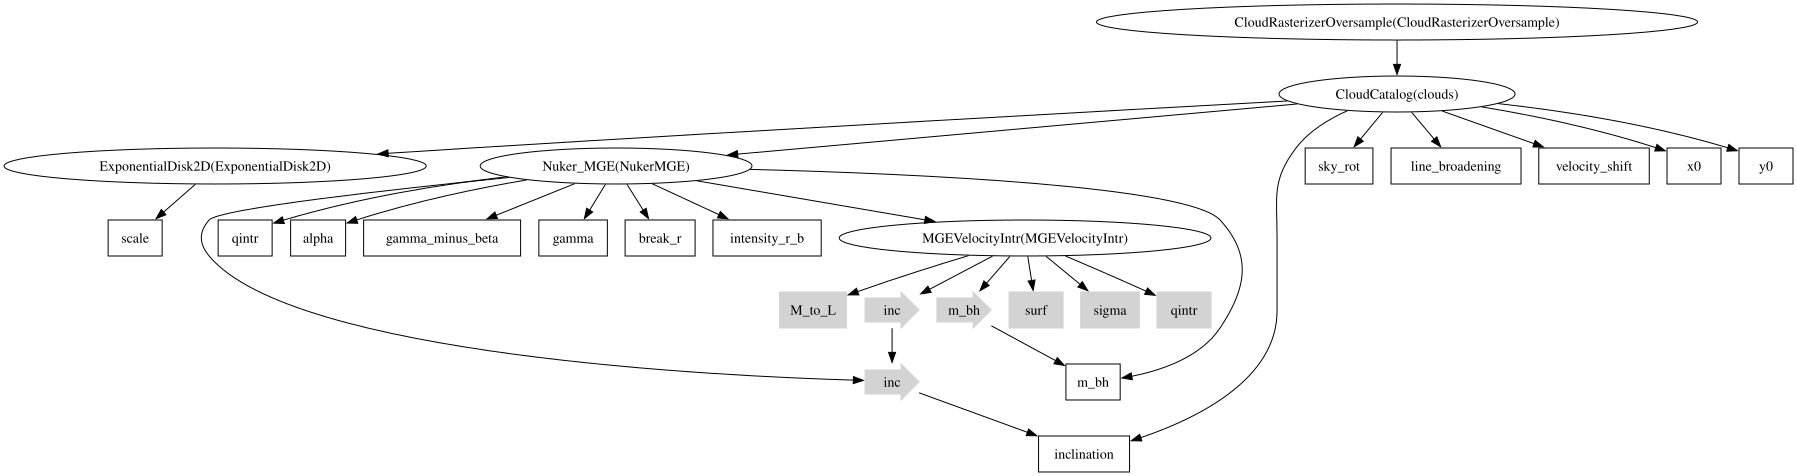

In [8]:
renderer.graphviz()

In [9]:
print(renderer.dynamic_params)

(scale, m_bh, inclination, qintr, alpha, gamma_minus_beta, gamma, break_r, intensity_r_b, sky_rot, line_broadening, velocity_shift, x0, y0)


### Set up visibility simulator

In [10]:
vis_sim = VisibilityCubePadded(renderer, mask = torch.tensor(mask, device = device, dtype = dtype), freqs = freq, npix = num_pixels_uv, pixelscale = arcseconds_per_pixel)

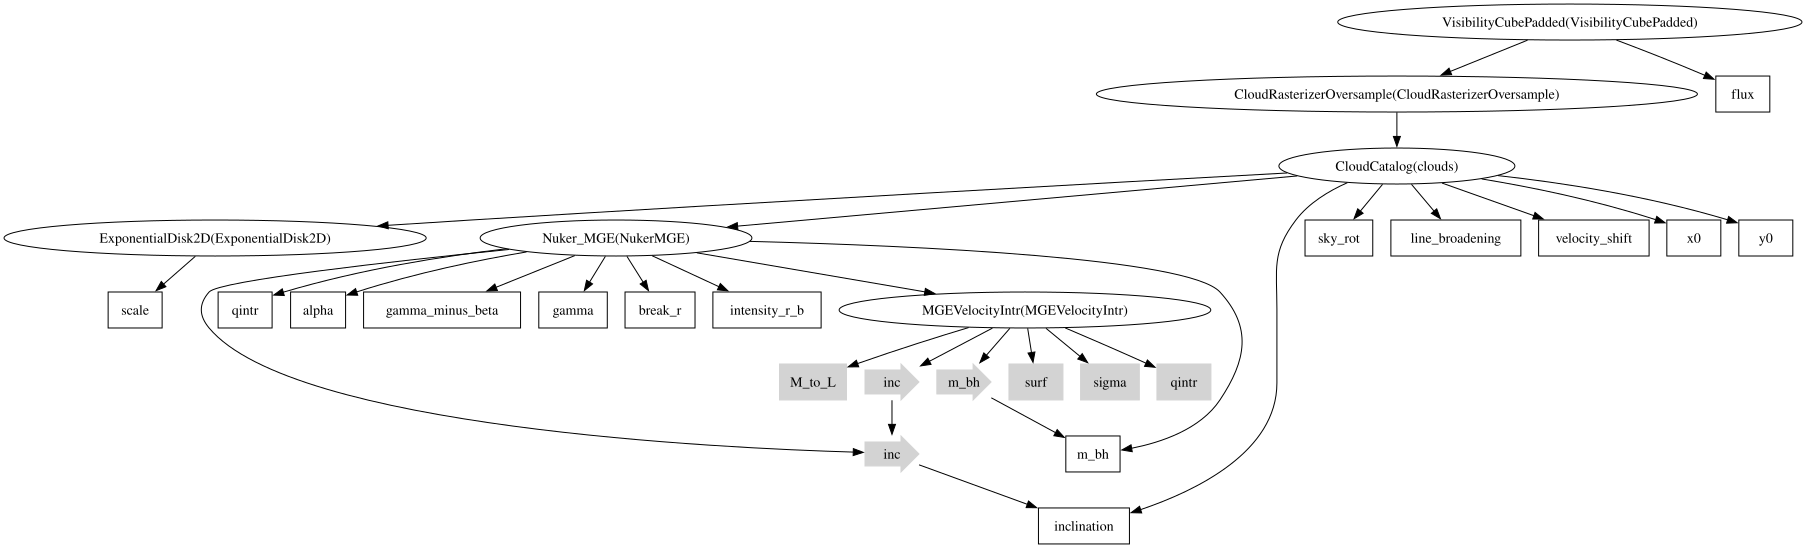

In [11]:
vis_sim.graphviz()

In [12]:
print(vis_sim.dynamic_params)

(scale, m_bh, inclination, qintr, alpha, gamma_minus_beta, gamma, break_r, intensity_r_b, sky_rot, line_broadening, velocity_shift, x0, y0, flux)


### Create an initialization array for dynamic parameters

In [13]:
initialization = np.array([ 7.21910019e+01,  8.07199955e+00,  1.38069999e+00,  7.00000000e-01,
        1.45430005e+00, -4.00400013e-01,  7.71790028e-01,  3.73550010e+00,
        4.31180000e+00,  4.30210018e+00,  2.57540011e+00,  1.24500000e+03,
        1.41310006e-01,  6.03680015e-01,  1.63299999e+01])
init_torch = torch.tensor(initialization, device = device, dtype = dtype)

### Generate simulated data

In [14]:
data = vis_sim.forward(init_torch)
vis_bin_re_cube = data.real.detach().cpu().numpy()
vis_bin_imag_cube = data.imag.detach().cpu().numpy()
std_grid_cube_real = np.ones(vis_bin_re_cube.shape)
std_grid_cube_imag = np.ones(vis_bin_imag_cube.shape)

### Generate dirty image from simulated data

In [15]:
from supermage.utils.plotting import dirty_cube_tool, velocity_map
# Define the region of interest for the cube (pixels 1000 to 1050)
roi_start, roi_end = 225, 276
fov_pixels = roi_end - roi_start
arcseconds_per_pixel = fov_arcseconds/num_pixels_uv

dirty_cube = dirty_cube_tool(vis_bin_re_cube, vis_bin_imag_cube, roi_start, roi_end)
extent = (-1*arcseconds_per_pixel*fov_pixels/2, arcseconds_per_pixel*fov_pixels/2, -1*arcseconds_per_pixel*fov_pixels/2, arcseconds_per_pixel*fov_pixels/2)

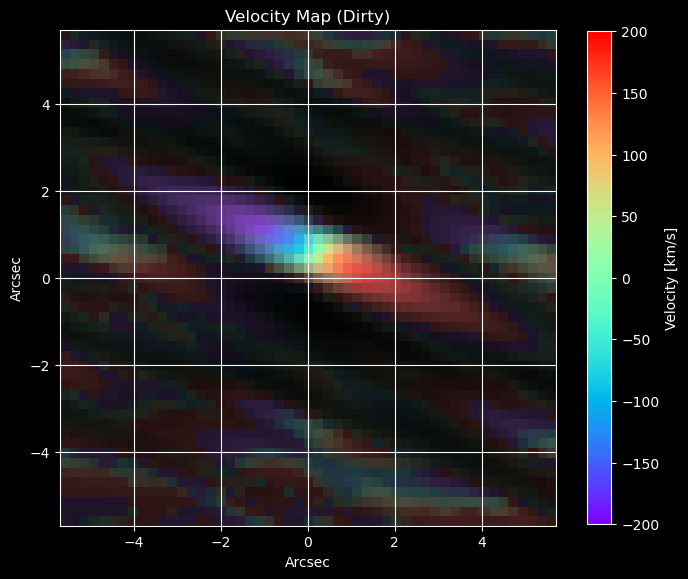

In [16]:
vel_map = velocity_map(dirty_cube, velocities)
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation, rc, colors

plt.style.use('dark_background')
fig, ax1 = plt.subplots(1, 1, figsize = (8, 8))
ax1.set_aspect('equal', adjustable='box')

divnorm=colors.TwoSlopeNorm(vcenter=0., vmin = -200, vmax = 200)
im11 = ax1.imshow(vel_map, cmap = "rainbow", norm = divnorm, origin = "lower",  extent=extent)
c_white = matplotlib.colors.colorConverter.to_rgba('white',alpha = 0)
c_black= matplotlib.colors.colorConverter.to_rgba('black',alpha = 1)
cmap_rb = matplotlib.colors.LinearSegmentedColormap.from_list('rb_cmap',[c_black, c_white],256)
im12 = ax1.imshow(np.sum(dirty_cube, axis = 2), cmap = cmap_rb, origin = "lower",  extent=extent)

fig.colorbar(im11, label = "Velocity [km/s]", shrink = 0.8)
ax1.set_xlabel("Arcsec")
ax1.set_ylabel("Arcsec")
ax1.set_title("Velocity Map (Dirty)")
plt.grid()
plt.show()